## Ahmed Series One

In [16]:
from experiment_analysis import experiments_from_series

experiments: [141, 142, 143, 144]
mapping: {141: 'Pull', 142: 'Round Robin', 143: 'Random', 144: 'Least Queue'}
saved: figures/free_request_capacity_with_inset.png


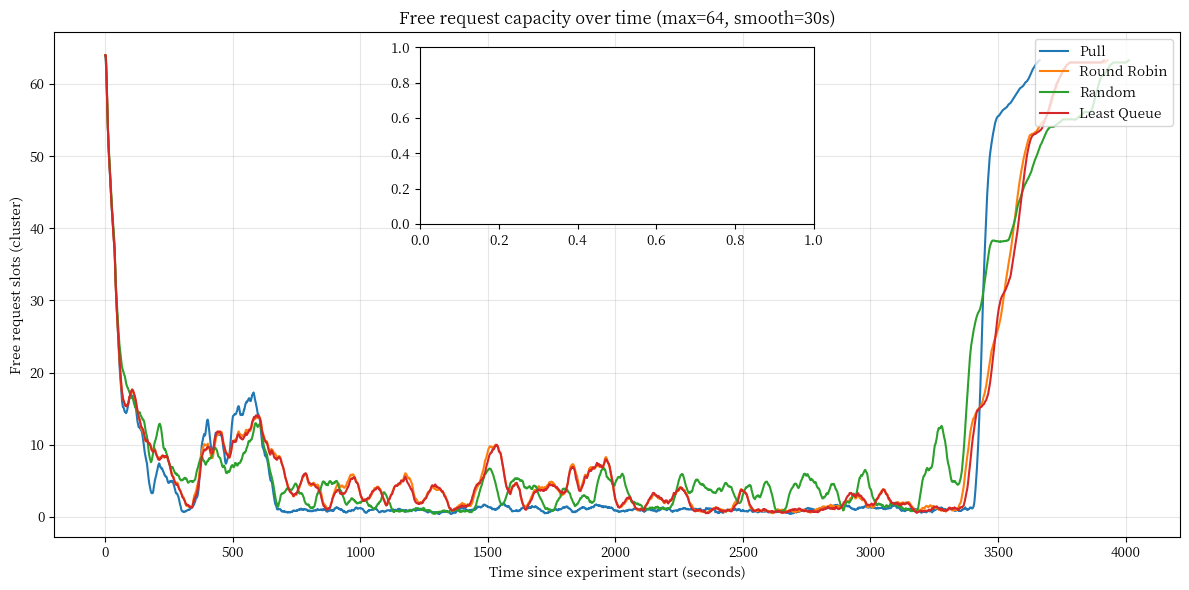

In [29]:
from experiment_analysis import load_experiment_prom_samples
import matplotlib.pyplot as plt
import os

# ---- choose experiments ----
series_ids = [35]
experiments = experiments_from_series(series_ids)
print("experiments:", experiments)

# Map experiments (in order) -> names
name_order = ["Pull", "Round Robin", "Random", "Least Queue"]
exp_name = {exp_id: name_order[i] for i, exp_id in enumerate(experiments[:len(name_order)])}
print("mapping:", exp_name)

# ----------------------------
metric = "requests_running"
MAX_REQUEST_CAPACITY = 64
SMOOTHING_WINDOW_S = 30

agg_mode = "sum"
# agg_mode = "mean"

# ---- magnifier zoom window in TIME ----
ZOOM_T_START = 8000
ZOOM_T_END   = 8060

# ---- inset box placement in AXES coordinates (guaranteed inside) ----
INSET_RECT = [0.325, 0.62, 0.35, 0.35]
# -----------------------------------------------

plt.figure(figsize=(12, 6))
ax = plt.gca()

series_by_name = {}

for exp_id in experiments:
    prom = load_experiment_prom_samples(exp_id=exp_id)

    if prom.empty:
        print(f"Skipping exp{exp_id}: no prom samples")
        continue
    if metric not in prom.columns:
        print(f"Skipping exp{exp_id}: {metric} not found")
        continue

    prom = prom.sort_values("ts").reset_index(drop=True)

    t0 = prom["ts"].min()
    prom["t_rel_s"] = (prom["ts"] - t0).dt.total_seconds()

    if agg_mode == "sum":
        running = prom.groupby("t_rel_s")[metric].sum(min_count=1)
        capacity = MAX_REQUEST_CAPACITY
        y_label = "Free request slots (cluster)"
    else:
        running = prom.groupby("t_rel_s")[metric].mean()
        capacity = MAX_REQUEST_CAPACITY
        y_label = "Free request slots (per instance avg)"

    free_slots = (capacity - running).clip(lower=0)

    if SMOOTHING_WINDOW_S and SMOOTHING_WINDOW_S > 1:
        free_slots = free_slots.rolling(window=SMOOTHING_WINDOW_S, min_periods=1).mean()

    label = exp_name.get(exp_id, f"exp{exp_id}")
    ax.plot(free_slots.index, free_slots.values, label=label)
    series_by_name[label] = free_slots

ax.set_xlabel("Time since experiment start (seconds)")
ax.set_ylabel(y_label)
ax.set_title(f"Free request capacity over time (max={MAX_REQUEST_CAPACITY}, smooth={SMOOTHING_WINDOW_S}s)")
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)

# ---- inset (magnifier) ----
if series_by_name:
    axins = ax.inset_axes(INSET_RECT)

    zoom_ymins, zoom_ymaxs = [], []

    for label, free_slots in series_by_name.items():
        zoomed = free_slots.loc[(free_slots.index >= ZOOM_T_START) & (free_slots.index <= ZOOM_T_END)]
        if zoomed.empty:
            continue
        axins.plot(zoomed.index, zoomed.values)
        zoom_ymins.append(float(zoomed.min()))
        zoom_ymaxs.append(float(zoomed.max()))

    if zoom_ymins:
        axins.set_xlim(ZOOM_T_START, ZOOM_T_END)

        y0, y1 = min(zoom_ymins), max(zoom_ymaxs)
        pad = max(1e-9, 0.08 * (y1 - y0))
        axins.set_ylim(y0 - pad, y1 + pad)

        axins.set_xticks([])
        axins.set_yticks([])
        axins.grid(True, alpha=0.2)

        ax.indicate_inset_zoom(axins, edgecolor="0.5")

plt.tight_layout()

os.makedirs("figures", exist_ok=True)
out_path = "figures/free_request_capacity_with_inset.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
print("saved:", out_path)

experiments: [161, 162, 163, 164]
总帧数: 946
预计视频时长: 189.2 秒
saved: figures/vllm-utilization_v1.mp4


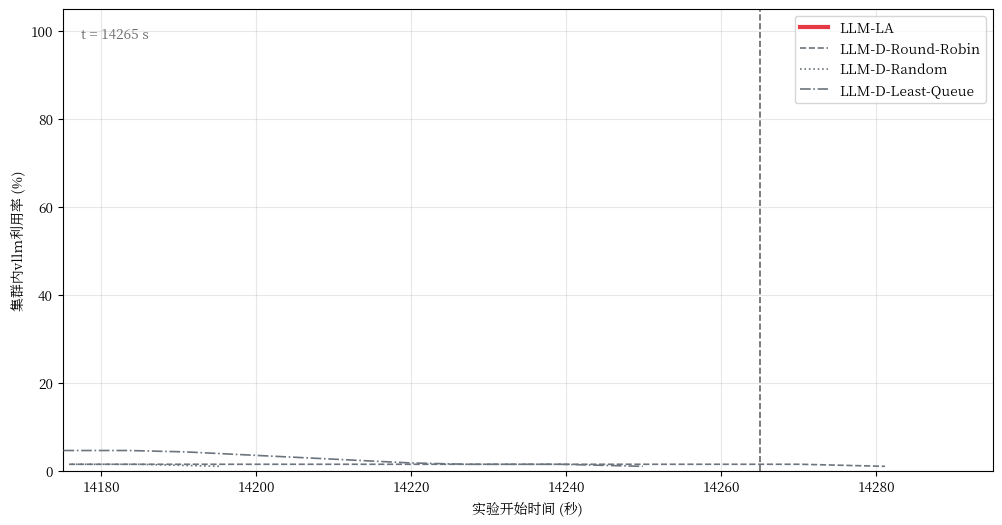

In [5]:
import os
os.makedirs(os.path.expanduser("~/.cache/matplotlib"), exist_ok=True)
from mplfonts.bin.cli import init
init()
from mplfonts import use_font
use_font('Noto Serif CJK SC')
from experiment_analysis import load_experiment_prom_samples
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np

# ---- choose experiments ----
series_ids = [40]
experiments = experiments_from_series(series_ids)
print("experiments:", experiments)

name_order = ["LLM-LA", "LLM-D-Round-Robin", "LLM-D-Random", "LLM-D-Least-Queue"]
exp_name = {exp_id: name_order[i] for i, exp_id in enumerate(experiments[:len(name_order)])}

# ----------------------------
metric = "requests_running"
MAX_REQUEST_CAPACITY = 64
SMOOTHING_WINDOW_S = 30
agg_mode = "sum"

WINDOW_WIDTH_S = 120
FPS = 5
STEP_S = 15
SAVE_MP4 = True

# ---- 加载数据 ----
series_by_name = {}
y_label = "集群内vllm利用率 (%)"
for exp_id in experiments:
    prom = load_experiment_prom_samples(exp_id=exp_id)
    if prom.empty or metric not in prom.columns:
        continue
    prom = prom.sort_values("ts").reset_index(drop=True)
    t0 = prom["ts"].min()
    prom["t_rel_s"] = (prom["ts"] - t0).dt.total_seconds()

    if agg_mode == "sum":
        running = prom.groupby("t_rel_s")[metric].sum(min_count=1)
    else:
        running = prom.groupby("t_rel_s")[metric].mean()

    free_slots = ((running / MAX_REQUEST_CAPACITY) * 100).clip(lower=0)
    if SMOOTHING_WINDOW_S and SMOOTHING_WINDOW_S > 1:
        free_slots = free_slots.rolling(window=SMOOTHING_WINDOW_S, min_periods=1).mean()

    label = exp_name.get(exp_id, f"exp{exp_id}")
    series_by_name[label] = free_slots

if not series_by_name:
    raise RuntimeError("没有加载到任何数据，请检查 series_ids 和 metric 设置")

# ---- 计算全局时间范围 ----
all_times = np.concatenate([s.index.values for s in series_by_name.values()])
T_MIN = float(all_times.min())
T_MAX = float(all_times.max())

# ---- 动画帧列表 ----
frame_starts = np.arange(T_MIN, T_MAX - WINDOW_WIDTH_S + STEP_S, STEP_S)
print(f"总帧数: {len(frame_starts)}")
print(f"预计视频时长: {len(frame_starts) / FPS:.1f} 秒")

# ---- 创建图 ----
fig, ax = plt.subplots(figsize=(12, 6))

line_styles = {
    "LLM-LA":            {"color": "#e63946", "lw": 3.0, "ls": "-",  "zorder": 5},
    "LLM-D-Round-Robin": {"color": "#6c757d", "lw": 1.2, "ls": "--", "zorder": 3},
    "LLM-D-Random":      {"color": "#6c757d", "lw": 1.2, "ls": ":",  "zorder": 3},
    "LLM-D-Least-Queue": {"color": "#6c757d", "lw": 1.2, "ls": "-.", "zorder": 3},
}

lines = {}
for label in series_by_name:
    style = line_styles.get(label, {"color": "gray", "lw": 1.2, "ls": "-", "zorder": 3})
    line, = ax.plot([], [], label=label,
                    color=style["color"], lw=style["lw"],
                    ls=style["ls"], zorder=style["zorder"])
    lines[label] = line

vline = ax.axvline(x=0, color='black', lw=1.2, ls='--', alpha=0.6, label='_nolegend_')

ax.set_xlabel("实验开始时间 (秒)")
ax.set_ylabel(y_label)
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 105)

time_text = ax.text(0.02, 0.96, '', transform=ax.transAxes,
                    fontsize=10, va='top', color='dimgray')

def init():
    for line in lines.values():
        line.set_data([], [])
    vline.set_xdata([T_MIN])
    time_text.set_text('')
    ax.set_xlim(T_MIN, T_MIN + WINDOW_WIDTH_S)
    return list(lines.values()) + [vline, time_text]

def update(frame_idx):
    t_start = frame_starts[frame_idx]
    t_end   = t_start + WINDOW_WIDTH_S
    ax.set_xlim(t_start, t_end)
    ax.set_ylim(0, 105)

    t_cursor = t_start + WINDOW_WIDTH_S * 0.75
    vline.set_xdata([t_cursor])
    time_text.set_text(f"t = {t_cursor:.0f} s")

    for label, free_slots in series_by_name.items():
        mask = (free_slots.index >= t_start) & (free_slots.index <= t_end)
        seg = free_slots.loc[mask]
        lines[label].set_data(seg.index.values, seg.values)

    return list(lines.values()) + [vline, time_text]

ani = animation.FuncAnimation(
    fig, update, frames=len(frame_starts),
    init_func=init, blit=True, interval=1000 / FPS
)

os.makedirs("figures", exist_ok=True)
out_path = "figures/vllm-utilization_v1.mp4"
ani.save(out_path, writer="ffmpeg", fps=FPS)
print("saved:", out_path)

In [6]:
print("\n=== 各算法平均利用率 ===")
for label in name_order:
    if label in series_by_name:
        mean_val = series_by_name[label].mean()
        print(f"{label}: {mean_val:.2f}%")


=== 各算法平均利用率 ===
LLM-LA: 96.20%
LLM-D-Round-Robin: 92.04%
LLM-D-Random: 92.52%
LLM-D-Least-Queue: 92.50%


[161, 162, 163, 164]


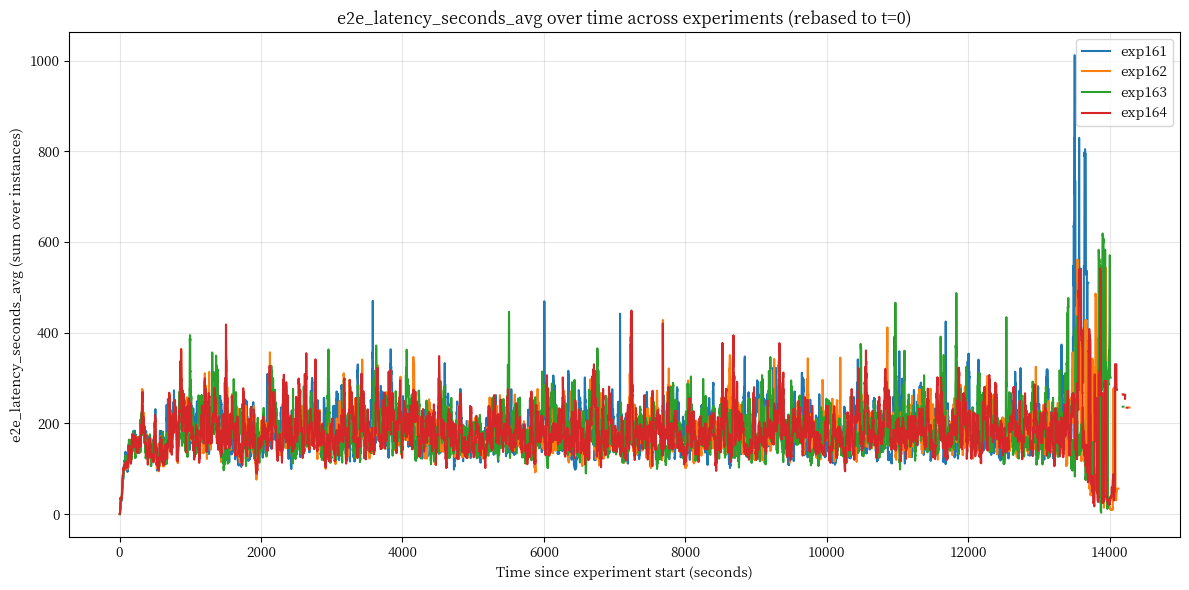

In [15]:
from experiment_analysis import load_experiment_prom_samples
import matplotlib.pyplot as plt

# ---- choose experiments ----
# choose which series you want
series_ids = [40]

experiments = experiments_from_series(series_ids)

print(experiments)
# ----------------------------

# ---- choose ONE metric (uncomment exactly one) ----
# metric = "requests_running"
# metric = "gen_tokens_per_sec"
# metric = "prefill_tokens_per_sec"
# metric = "request_success_per_sec"
# metric = "request_failure_per_sec"
# metric = "preemptions_per_sec"
# metric = "gpu_kv_cache_usage_frac"
# metric = "cpu_kv_cache_usage_frac"
# metric = "requests_waiting"
# metric = "ttft_seconds_avg"
# metric = "tpot_seconds_avg"
metric = "e2e_latency_seconds_avg"
# metric = "queue_time_seconds_avg"
# metric = "inference_time_seconds_avg"
# metric = "prefill_time_seconds_avg"
# metric = "decode_time_seconds_avg"
# metric = "request_prompt_tokens_avg"
# metric = "request_generation_tokens_avg"
# metric = "request_max_generation_tokens_avg"
# metric = "spec_tokens_accepted_per_sec"
# metric = "spec_tokens_draft_per_sec"
# metric = "spec_tokens_emitted_per_sec"

# -----------------------------------------------

# ---- how to aggregate across instances per timestamp ----
agg_mode = "sum"   # cluster-level
# agg_mode = "mean"  # per-instance average
# -----------------------------------------------

plt.figure(figsize=(12, 6))

for exp_id in experiments:
    prom = load_experiment_prom_samples(exp_id=exp_id)

    if prom.empty:
        print(f"Skipping exp{exp_id}: no prom samples")
        continue
    if metric not in prom.columns:
        print(f"Skipping exp{exp_id}: {metric} not found")
        continue

    prom = prom.sort_values("ts").reset_index(drop=True)

    # Rebase time: each experiment starts at t=0
    t0 = prom["ts"].min()
    prom["t_rel_s"] = (prom["ts"] - t0).dt.total_seconds()

    # Aggregate across instances per tick
    if agg_mode == "sum":
        series = prom.groupby("t_rel_s")[metric].sum(min_count=1)
        y_label = f"{metric} (sum over instances)"
    else:
        series = prom.groupby("t_rel_s")[metric].mean()
        y_label = f"{metric} (mean over instances)"

    x = series.index
    y = series.values

    plt.plot(x, y, label=f"exp{exp_id}")

plt.xlabel("Time since experiment start (seconds)")
plt.ylabel(y_label)
plt.title(f"{metric} over time across experiments (rebased to t=0)")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)
plt.tight_layout()


[141, 142, 143, 144]
[WARN] sidecar_* metrics live on vLLM (:8200) rows. Switching view -> 'vllm'.


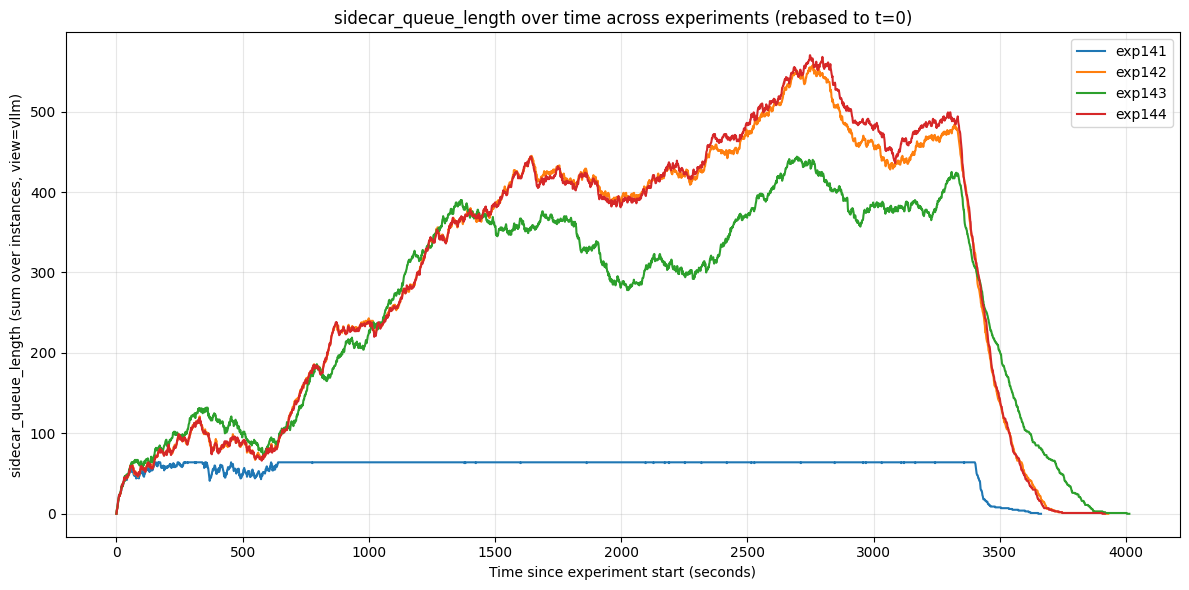

In [3]:
from experiment_analysis import load_experiment_prom_samples
import matplotlib.pyplot as plt
import pandas as pd

# ---- choose experiments ----
# choose which series you want
series_ids = [35]

experiments = experiments_from_series(series_ids)

print(experiments)
# ----------------------------

# ============================================================
# METRICS ONLY (router + sidecar)
# Choose ONE metric (uncomment exactly one)
# ============================================================

# --- Router metrics ---
# metric = "router_queue_length"
# metric = "router_admission_rps"
# metric = "router_outgoing_rps"

# --- Sidecar metrics ---
metric = "sidecar_queue_length"
# metric = "sidecar_received_rps"
# metric = "sidecar_completed_rps"

# ============================================================
# Which "view" to plot?
#   - "router" : use :8080 rows (ground truth router pod)
#   - "vllm"   : use :8200 rows (broadcast router_* + mapped sidecar_*)
#
# Recommended:
#   - router_* -> view="router"
#   - sidecar_*-> view="vllm"
# ============================================================
view = "router"   # "router" or "vllm"

# ---- how to aggregate across instances per timestamp ----
agg_mode = "sum"    # "sum" (cluster-level) or "mean" (per-instance average)
# ---------------------------------------------------------

def _port_of_instance(inst: str):
    try:
        _, port = str(inst).rsplit(":", 1)
        return int(port)
    except Exception:
        return None

def _subset_by_port(df: pd.DataFrame, port: int) -> pd.DataFrame:
    if df.empty:
        return df
    ports = df["instance"].map(_port_of_instance)
    return df.loc[ports == port].copy()

# Auto-pick a sensible default view if user forgets
if view not in ("router", "vllm"):
    raise ValueError("view must be 'router' or 'vllm'")

if metric.startswith("sidecar_") and view == "router":
    print("[WARN] sidecar_* metrics live on vLLM (:8200) rows. Switching view -> 'vllm'.")
    view = "vllm"

if metric.startswith("router_") and view == "vllm":
    print("[NOTE] plotting router_* from vLLM (:8200) rows uses the broadcast values.")
    print("       If you want router ground-truth, set view='router'.")

plt.figure(figsize=(12, 6))

for exp_id in experiments:
    prom = load_experiment_prom_samples(exp_id=exp_id)

    if prom.empty:
        print(f"Skipping exp{exp_id}: no prom samples")
        continue

    prom = prom.sort_values("ts").reset_index(drop=True)

    # Pick the right rows
    if view == "router":
        df = _subset_by_port(prom, 8080)
    else:
        df = _subset_by_port(prom, 8200)

    if df.empty:
        print(f"Skipping exp{exp_id}: no rows for view={view!r}")
        continue

    if metric not in df.columns:
        print(f"Skipping exp{exp_id}: {metric} not found in view={view!r}")
        continue

    # Rebase time: each experiment starts at t=0 within this view
    t0 = df["ts"].min()
    df["t_rel_s"] = (df["ts"] - t0).dt.total_seconds()

    # Aggregate across instances per tick (NaNs ignored; if all NaN at tick -> NaN)
    if agg_mode == "sum":
        series = df.groupby("t_rel_s")[metric].sum(min_count=1)
        y_label = f"{metric} (sum over instances, view={view})"
    elif agg_mode == "mean":
        series = df.groupby("t_rel_s")[metric].mean()
        y_label = f"{metric} (mean over instances, view={view})"
    else:
        raise ValueError("agg_mode must be 'sum' or 'mean'")

    x = series.index
    y = series.values

    plt.plot(x, y, label=f"exp{exp_id}")

plt.xlabel("Time since experiment start (seconds)")
plt.ylabel(y_label)
plt.title(f"{metric} over time across experiments (rebased to t=0)")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)
plt.tight_layout()


[141, 142, 143, 144]
[exp 141] corrected_requests=0/9976
[exp 142] corrected_requests=0/9964
[exp 143] corrected_requests=0/9974
[exp 144] corrected_requests=0/9962


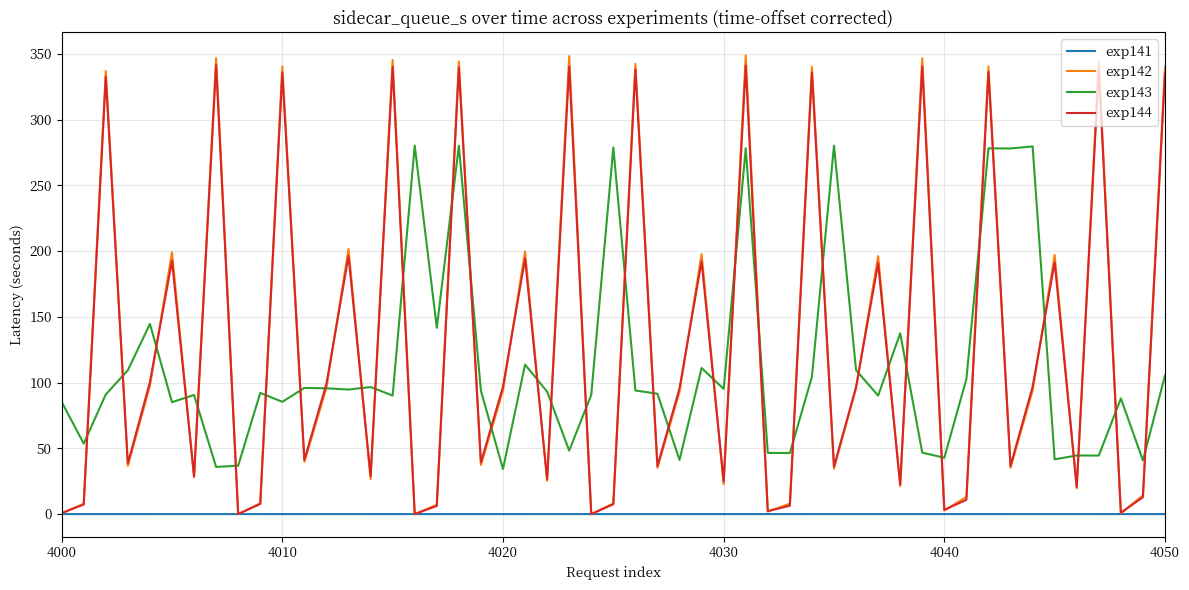

In [14]:
from experiment_analysis import load_experiment_latencies, experiments_from_series
import matplotlib.pyplot as plt

# ---- choose experiments ----
series_ids = [35]
experiments = experiments_from_series(series_ids)
# experiments = [142]
print(experiments)

# ============================================================
# FLAGS / CONFIG
# ============================================================
APPLY_TIME_OFFSETS = True   # set False to revert to raw clocks
X_START            = 4000   # first request index to show; None = from beginning
X_END              = 4050   # last request index to show;  None = to end
# ============================================================

# ---- choose ONE metric (uncomment exactly one) ----
# metric = "end_to_end_s"          # total client → router → server → client
# metric = "server_roundtrip_s"  # router → vLLM → router
# metric = "router_queue_s"      # waiting time in router queue
# metric = "router_to_sidecar_s" # router → sidecar hop
metric = "sidecar_queue_s"     # waiting time inside sidecar
# metric = "vllm_compute_s"      # actual model compute time
# metric = "router_post_result_s"
# ---------------------------------------------------

plt.figure(figsize=(12, 6))
for exp_id in experiments:
    df = (
        load_experiment_latencies(
            exp_id=exp_id,
            apply_time_offset_correction=APPLY_TIME_OFFSETS,
        )
        .sort_values("idx")
        .reset_index(drop=True)
    )

    if APPLY_TIME_OFFSETS and "applied_time_offset_s" in df.columns:
        n_corr = int(df["applied_time_offset_s"].notna().sum())
        print(f"[exp {exp_id}] corrected_requests={n_corr}/{len(df)}")

    if metric not in df.columns:
        print(f"Skipping exp{exp_id}: {metric} not found")
        continue

    # apply x-axis window filter
    mask = slice(None)
    if X_START is not None or X_END is not None:
        mask = (
            (df["idx"] >= (X_START if X_START is not None else df["idx"].min())) &
            (df["idx"] <= (X_END   if X_END   is not None else df["idx"].max()))
        )
        df = df[mask]

    x = df["idx"]
    y = df[metric]
    plt.plot(x, y, label=f"exp{exp_id}")

plt.xlabel("Request index")
plt.ylabel("Latency (seconds)")
plt.title(
    f"{metric} over time across experiments "
    + ("(time-offset corrected)" if APPLY_TIME_OFFSETS else "(raw clocks)")
)
if X_START is not None or X_END is not None:
    plt.xlim(left=X_START, right=X_END)
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

[141, 142, 143, 144]
总帧数: 81，预计时长: 16.2s
saved: figures/latency_start_3500_to_4000_exp35.mp4


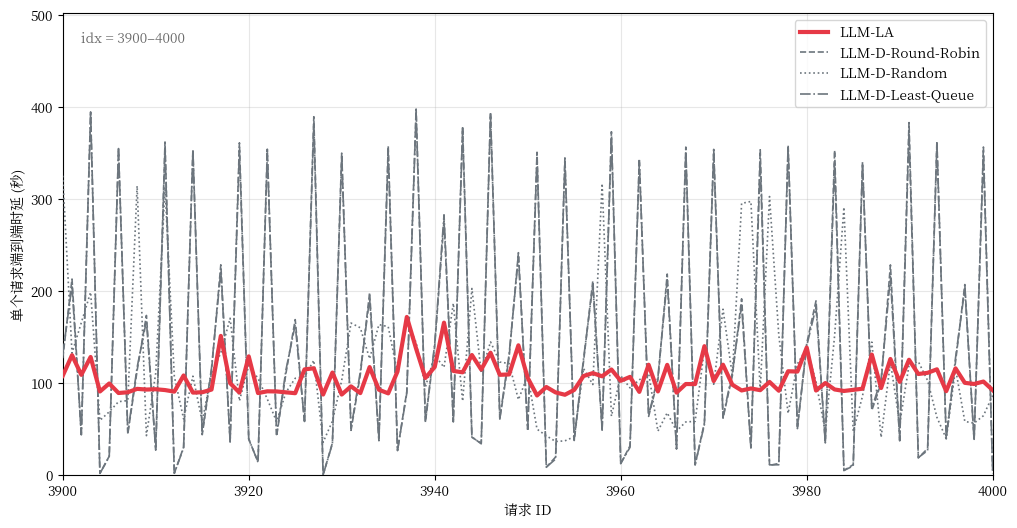

In [31]:
from experiment_analysis import load_experiment_latencies, experiments_from_series
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np
import os
os.makedirs(os.path.expanduser("~/.cache/matplotlib"), exist_ok=True)
from mplfonts.bin.cli import init
init()
from mplfonts import use_font
use_font('Noto Serif CJK SC')
# ---- choose experiments ----
series_ids = [35]
experiments = experiments_from_series(series_ids)
print(experiments)

# ============================================================
APPLY_TIME_OFFSETS = True
metric = "end_to_end_s"

WINDOW_WIDTH   = 100#200    # 每帧显示的 request 数量
STEP           = 5     # 每帧滑动的 request 数
IDX_START      = 3500
IDX_END        = 4000
FPS            = 5
SAVE_GIF       = True
# ============================================================

name_order = ["LLM-LA", "LLM-D-Round-Robin", "LLM-D-Random", "LLM-D-Least-Queue"]
exp_name   = {exp_id: name_order[i] for i, exp_id in enumerate(experiments[:len(name_order)])}

line_styles = {
    "LLM-LA":            {"color": "#e63946", "lw": 3.0, "ls": "-",  "zorder": 5},
    "LLM-D-Round-Robin": {"color": "#6c757d", "lw": 1.2, "ls": "--", "zorder": 3},
    "LLM-D-Random":      {"color": "#6c757d", "lw": 1.2, "ls": ":",  "zorder": 3},
    "LLM-D-Least-Queue": {"color": "#6c757d", "lw": 1.2, "ls": "-.", "zorder": 3},
}

# ---- 加载数据 ----
series_by_name = {}
for exp_id in experiments:
    df = (
        load_experiment_latencies(
            exp_id=exp_id,
            apply_time_offset_correction=APPLY_TIME_OFFSETS,
        )
        .sort_values("idx")
        .reset_index(drop=True)
    )
    if metric not in df.columns:
        print(f"Skipping exp{exp_id}: {metric} not found")
        continue
    df = df[(df["idx"] >= IDX_START) & (df["idx"] <= IDX_END)]
    label = exp_name.get(exp_id, f"exp{exp_id}")
    series_by_name[label] = df.set_index("idx")[metric]

if not series_by_name:
    raise RuntimeError("没有加载到任何数据")

# ---- 动画帧 ----
frame_starts = np.arange(IDX_START, IDX_END - WINDOW_WIDTH + STEP, STEP)
print(f"总帧数: {len(frame_starts)}，预计时长: {len(frame_starts)/FPS:.1f}s")

# ---- 全局 y 轴上限（排除极端离群值）----
all_vals = np.concatenate([s.values for s in series_by_name.values()])
Y_MAX = float(np.percentile(all_vals[np.isfinite(all_vals)], 99)) * 1.2

# ---- 创建图 ----
fig, ax = plt.subplots(figsize=(12, 6))

lines = {}
for label in name_order:
    if label not in series_by_name:
        continue
    style = line_styles[label]
    line, = ax.plot([], [], label=label,
                    color=style["color"], lw=style["lw"],
                    ls=style["ls"], zorder=style["zorder"])
    lines[label] = line

ax.set_xlabel("请求 ID")
ax.set_ylabel("单个请求端到端时延 (秒)")
# ax.set_title(f"{metric} — sliding window animation")
ax.set_ylim(0, Y_MAX)
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)

idx_text = ax.text(0.02, 0.96, '', transform=ax.transAxes,
                   fontsize=10, va='top', color='dimgray')

def init():
    for line in lines.values():
        line.set_data([], [])
    ax.set_xlim(IDX_START, IDX_START + WINDOW_WIDTH)
    idx_text.set_text('')
    return list(lines.values()) + [idx_text]

def update(frame_idx):
    x_start = int(frame_starts[frame_idx])
    x_end   = x_start + WINDOW_WIDTH
    ax.set_xlim(x_start, x_end)

    for label, series in series_by_name.items():
        seg = series[(series.index >= x_start) & (series.index <= x_end)]
        lines[label].set_data(seg.index.values, seg.values)

    idx_text.set_text(f"idx = {x_start}–{x_end}")
    return list(lines.values()) + [idx_text]

ani = animation.FuncAnimation(
    fig, update, frames=len(frame_starts),
    init_func=init, blit=True, interval=1000 / FPS
)

import os
os.makedirs("figures", exist_ok=True)
out_path = "figures/latency_start_3500_to_4000_exp35.mp4"
ani.save(out_path, writer="ffmpeg", fps=FPS)
print("saved:", out_path)

In [22]:
print("\n=== Shortest e2e latency ===")
for label in name_order:
    if label not in series_by_name:
        continue
    min_val = series_by_name[label].min()
    print(f"{label:25s}: {min_val:.4f} s")


=== Shortest e2e latency ===
LLM-LA                   : 23.3529 s
LLM-D-Round-Robin        : 0.2568 s
LLM-D-Random             : 0.2160 s
LLM-D-Least-Queue        : 0.2182 s


[161, 162, 163, 164]
[exp 161] corrected_requests=0/39884
[exp 162] corrected_requests=0/39846
[exp 163] corrected_requests=0/39799
[exp 164] corrected_requests=0/39791


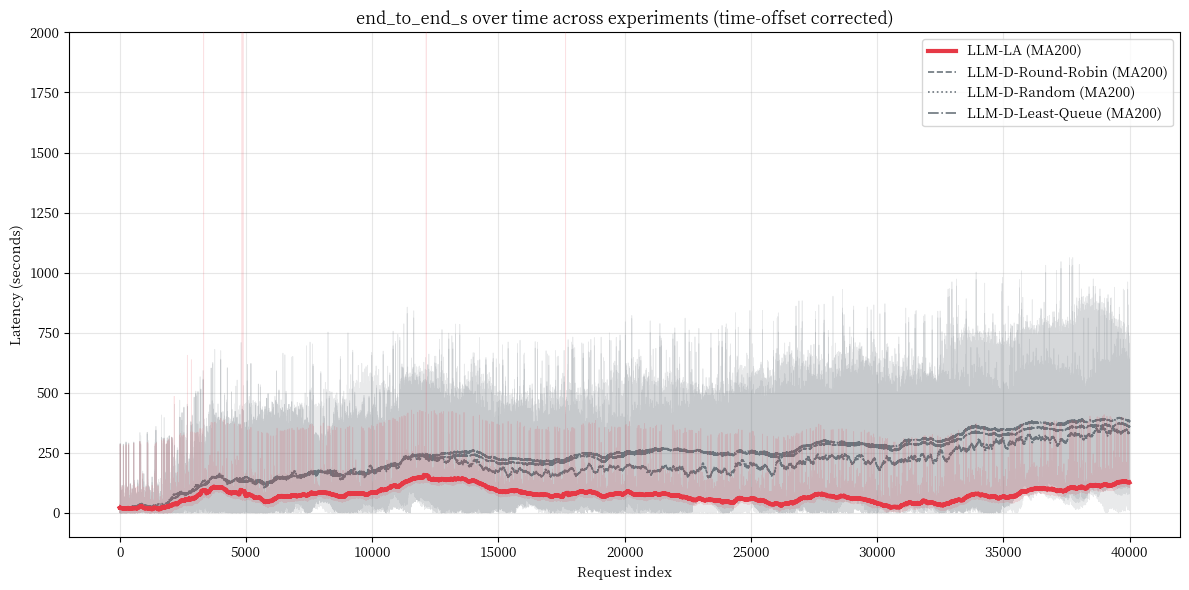

In [10]:
from experiment_analysis import load_experiment_latencies, experiments_from_series
import matplotlib.pyplot as plt
import pandas as pd

# ---- choose experiments ----
series_ids = [40]
experiments = experiments_from_series(series_ids)
print(experiments)

APPLY_TIME_OFFSETS = True
MA_WINDOW          = 200
Y_MAX              = 2000.0

metric = "end_to_end_s"

name_order = ["LLM-LA", "LLM-D-Round-Robin", "LLM-D-Random", "LLM-D-Least-Queue"]
exp_name = {exp_id: name_order[i] for i, exp_id in enumerate(experiments[:len(name_order)])}

line_styles = {
    "LLM-LA":            {"color": "#e63946", "lw": 3.0, "ls": "-",  "zorder": 5},
    "LLM-D-Round-Robin": {"color": "#6c757d", "lw": 1.2, "ls": "--", "zorder": 3},
    "LLM-D-Random":      {"color": "#6c757d", "lw": 1.2, "ls": ":",  "zorder": 3},
    "LLM-D-Least-Queue": {"color": "#6c757d", "lw": 1.2, "ls": "-.", "zorder": 3},
}

fig, ax = plt.subplots(figsize=(12, 6))

for exp_id in experiments:
    df = (
        load_experiment_latencies(
            exp_id=exp_id,
            apply_time_offset_correction=APPLY_TIME_OFFSETS,
        )
        .sort_values("idx")
        .reset_index(drop=True)
    )
    if APPLY_TIME_OFFSETS and "applied_time_offset_s" in df.columns:
        n_corr = int(df["applied_time_offset_s"].notna().sum())
        print(f"[exp {exp_id}] corrected_requests={n_corr}/{len(df)}")
    if metric not in df.columns:
        print(f"Skipping exp{exp_id}: {metric} not found")
        continue

    label = exp_name.get(exp_id, f"exp{exp_id}")
    style = line_styles.get(label, {"color": "gray", "lw": 1.2, "ls": "-", "zorder": 3})

    x = df["idx"]
    y = df[metric].clip(upper=Y_MAX) if Y_MAX is not None else df[metric]

    ax.plot(x, y, color=style["color"], alpha=0.15, linewidth=0.6, zorder=style["zorder"])
    ma = y.rolling(window=MA_WINDOW, center=True, min_periods=1).mean()
    # ax.plot(x, ma, color=style["color"], linewidth=style["lw"],
    #         ls=style["ls"], zorder=style["zorder"], label=f"{label} (MA{MA_WINDOW})")
    
    ax.plot(x, ma, color=style["color"], linewidth=style["lw"],
            ls=style["ls"], zorder=style["zorder"], label=f"{label}")


ax.set_xlabel("Request index")
ax.set_ylabel("单个Request端到端时延 (seconds)")
ax.set_title(
    f"{metric} over time across experiments "
    + ("(time-offset corrected)" if APPLY_TIME_OFFSETS else "(raw clocks)")
)
if Y_MAX is not None:
    ax.set_ylim(top=Y_MAX)
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

[141, 142, 143, 144]
[exp 141] corrected_requests=0/9976
[exp 142] corrected_requests=0/9964
[exp 143] corrected_requests=0/9974
[exp 144] corrected_requests=0/9962


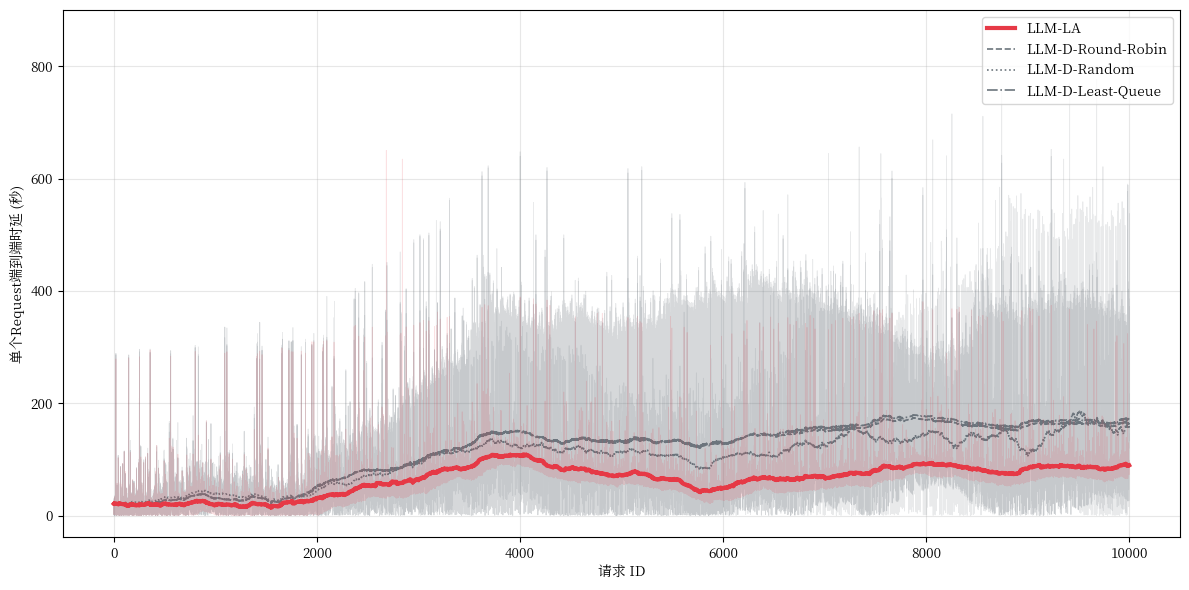

In [35]:
from experiment_analysis import load_experiment_latencies, experiments_from_series
import matplotlib.pyplot as plt
import pandas as pd

# ---- choose experiments ----
series_ids = [35]
experiments = experiments_from_series(series_ids)
print(experiments)

APPLY_TIME_OFFSETS = True
MA_WINDOW          = 200
Y_MAX              = 900.0
metric = "end_to_end_s"

name_order = ["LLM-LA", "LLM-D-Round-Robin", "LLM-D-Random", "LLM-D-Least-Queue"]
exp_name = {exp_id: name_order[i] for i, exp_id in enumerate(experiments[:len(name_order)])}

line_styles = {
    "LLM-LA":            {"color": "#e63946", "lw": 3.0, "ls": "-",  "zorder": 5},
    "LLM-D-Round-Robin": {"color": "#6c757d", "lw": 1.2, "ls": "--", "zorder": 3},
    "LLM-D-Random":      {"color": "#6c757d", "lw": 1.2, "ls": ":",  "zorder": 3},
    "LLM-D-Least-Queue": {"color": "#6c757d", "lw": 1.2, "ls": "-.", "zorder": 3},
}

fig, ax = plt.subplots(figsize=(12, 6))

for exp_id in experiments:
    df = (
        load_experiment_latencies(
            exp_id=exp_id,
            apply_time_offset_correction=APPLY_TIME_OFFSETS,
        )
        .sort_values("idx")
        .reset_index(drop=True)
    )

    if APPLY_TIME_OFFSETS and "applied_time_offset_s" in df.columns:
        n_corr = int(df["applied_time_offset_s"].notna().sum())
        print(f"[exp {exp_id}] corrected_requests={n_corr}/{len(df)}")

    if metric not in df.columns:
        print(f"Skipping exp{exp_id}: {metric} not found")
        continue

    label = exp_name.get(exp_id, f"exp{exp_id}")
    style = line_styles.get(label, {"color": "gray", "lw": 1.2, "ls": "-", "zorder": 3})

    y_raw = df[metric]
    mask  = y_raw <= 1250
    y     = y_raw[mask]
    x     = df.loc[mask, "idx"]

    ax.plot(x, y, color=style["color"], alpha=0.15, linewidth=0.6, zorder=style["zorder"])

    ma = y.rolling(window=MA_WINDOW, center=True, min_periods=1).mean()
    # ax.plot(x, ma, color=style["color"], linewidth=style["lw"],
    #         ls=style["ls"], zorder=style["zorder"], label=f"{label} (MA{MA_WINDOW})")
        
    ax.plot(x, ma, color=style["color"], linewidth=style["lw"],
            ls=style["ls"], zorder=style["zorder"], label=f"{label}")

ax.set_xlabel("请求 ID")
ax.set_ylabel("单个Request端到端时延 (秒)")
# ax.set_title(
#     f"{metric} over time across experiments "
#     + ("(time-offset corrected)" if APPLY_TIME_OFFSETS else "(raw clocks)")
# )
ax.set_ylim(top=Y_MAX)
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("figures/latency_ma_35.png", dpi=300, bbox_inches="tight")
plt.show()